# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

- Một dòng dữ liệu đại diên cho mức chi tiêu của 1 khách hàng (đơn vị là tiền tệ). Các feature có ý nghĩa: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.
- Missing/Duplicate: như bên dưới
- Giá trị 0 / cực trị: một số khách hàng có chi tiêu rất thấp ở `Detergents_Paper`/`Delicassen` (gần 0) trong khi một số khác chi hàng chục nghìn cho `Fresh`/`Grocery`.
- `Channel`/`Region`: nên dùng khi phân cụm xong không dùng để fit model. Nếu đưa thẳng vào input, mô hình sẽ học lại một phân loại đã biết trước thay vì các cấu trúc chi tiết.
- Hữu ích" trong business context: nghĩa là các cụm phải (i) đủ tách biệt để không phải nhiễu thống kê, (ii) có quy mô đủ lớn để đáng để thiết kế chính sách riêng (giá, khuyến mãi, danh mục sản phẩm), và (iii) diễn giải được bằng ngôn ngữ chi tiêu thực tế để đội sales/marketing có thể hành động.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
# display(X_raw.describe().T)
print("Missing value:")
print(df.isnull().sum())
print("Duplicate rows:")
print(df.duplicated().sum())
print("Thông kê X_raw:")
display(X_raw.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

Missing value:
Channel             0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Duplicate rows:
0
Thông kê X_raw:


,count,mean,std,min,50%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"8,504.00","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"3,627.00","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"4,755.50","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,"1,526.00","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,816.50,"40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,965.50,"47,943.00"


# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

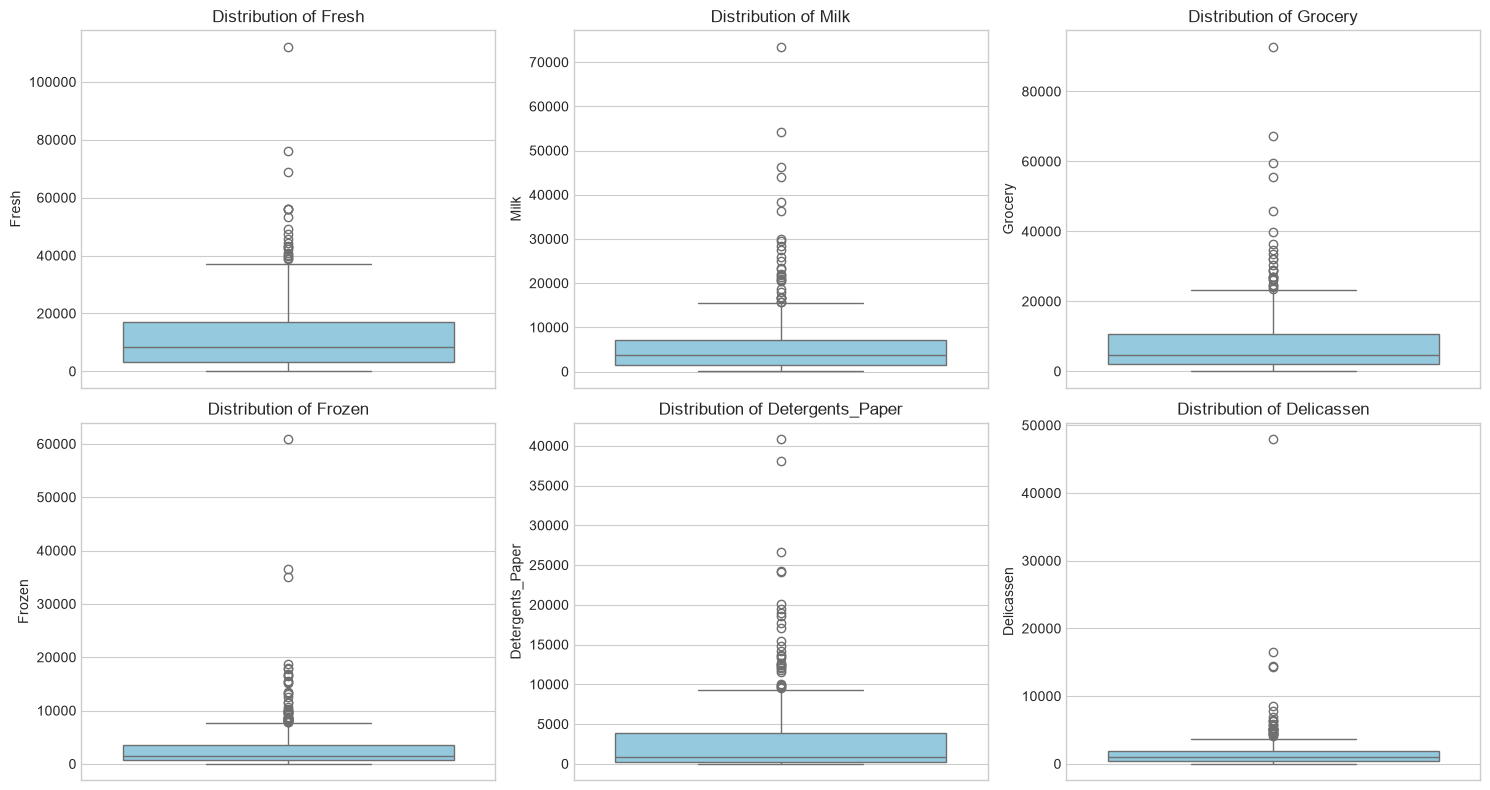

In [4]:
# Biểu đồ Boxplot và KDE trước khi biến đổi
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(SPENDING_FEATURES):
    sns.boxplot(y=X_raw[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

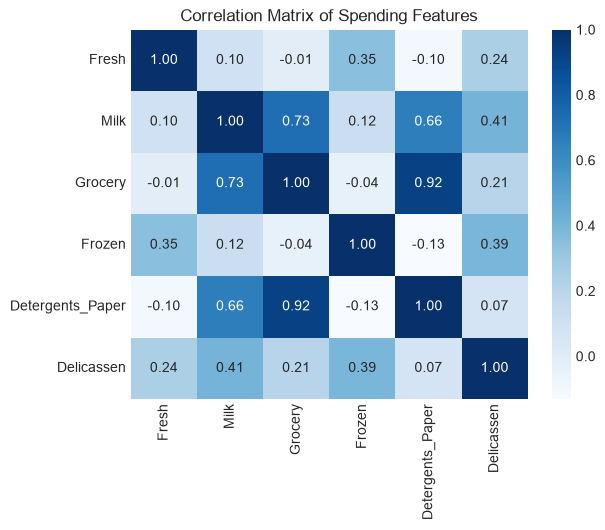

In [ ]:
# Correlation Matrix (ma trận tương quan)
plt.figure(figsize=(8, 6))
sns.heatmap(X_raw.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Matrix of Spending Features")
plt.show()

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

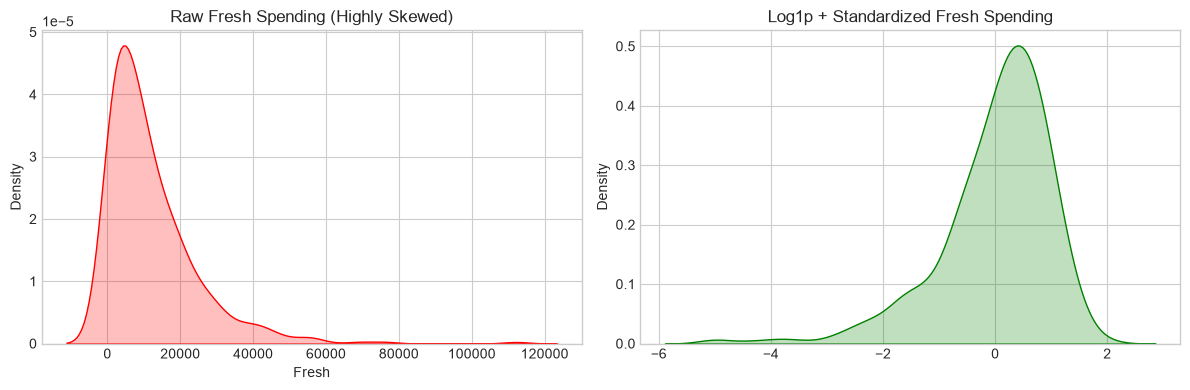

In [6]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))

# Pipeline A: Log1p + StandardScaler
X_log = np.log1p(X_raw)
scaler_log = StandardScaler()
X_scaled_log = scaler_log.fit_transform(X_log)

# Pipeline B: Raw + StandardScaler
scaler_raw = StandardScaler()
X_scaled_raw = scaler_raw.fit_transform(X_raw)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(X_raw['Fresh'], ax=ax1, color='red', fill=True)
ax1.set_title('Raw Fresh Spending (Highly Skewed)')
sns.kdeplot(X_scaled_log[:, 0], ax=ax2, color='green', fill=True)
ax2.set_title('Log1p + Standardized Fresh Spending')
plt.tight_layout()
plt.show()

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [7]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)

results = []
# 1. Evaluate K-Means
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled_log)
    sil = silhouette_score(X_scaled_log, labels)
    db = davies_bouldin_score(X_scaled_log, labels)
    results.append({
            'Algorithm': 'K-Means',
            'k': k,
            'Silhouette': sil,
            'Davies-Bouldin': db,
            'Noise Rate': 0.0
        })
# 2. Evaluate Agglomerative Clustering
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_scaled_log)
    sil = silhouette_score(X_scaled_log, labels)
    db = davies_bouldin_score(X_scaled_log, labels)
    results.append({
        'Algorithm': 'Agglomerative (Ward)',
        'k': k,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Noise Rate': 0.0
    })

# 3. Evaluate DBSCAN
for eps in [0.8, 1.0, 1.2, 1.5]:
    for min_samples in [5, 10]:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled_log)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            # Tính metric chỉ cho các điểm không phải noise
            mask = labels != -1
            if np.sum(mask) > n_clusters:
                sil = silhouette_score(X_scaled_log[mask], labels[mask])
                db = davies_bouldin_score(X_scaled_log[mask], labels[mask])
                noise_rate = np.mean(labels == -1)
                results.append({
                    'Algorithm': f'DBSCAN (eps={eps}, min={min_samples})',
                    'k': n_clusters,
                    'Silhouette': sil,
                    'Davies-Bouldin': db,
                    'Noise Rate': noise_rate
                })

df_res = pd.DataFrame(results)
display(df_res.sort_values(by='Silhouette', ascending=False))


,Algorithm,k,Silhouette,Davies-Bouldin,Noise Rate
11,"DBSCAN (eps=0.8, min=10)",2,0.54,0.71,0.76
0,K-Means,2,0.29,1.35,0.00
10,"DBSCAN (eps=0.8, min=5)",3,0.29,0.71,0.52
5,Agglomerative (Ward),2,0.26,1.60,0.00
1,K-Means,3,0.26,1.35,0.00
6,Agglomerative (Ward),3,0.25,1.54,0.00
8,Agglomerative (Ward),5,0.20,1.39,0.00
7,Agglomerative (Ward),4,0.20,1.52,0.00
4,K-Means,6,0.20,1.41,0.00
3,K-Means,5,0.19,1.48,0.00


# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [8]:
# Robustness test cho K-Means (k=2) qua Bootstrapping
np.random.seed(RANDOM_STATE)
km_base = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
base_labels = km_base.fit_predict(X_scaled_log)

ari_scores = []
n_iterations = 100

for i in range(n_iterations):
    # Subsample 80% dữ liệu
    sample_idx = np.random.choice(len(X_scaled_log), size=int(0.8 * len(X_scaled_log)), replace=False)
    X_sample = X_scaled_log[sample_idx]
    
    km_sub = KMeans(n_clusters=2, n_init=20, random_state=i)
    sub_labels = km_sub.fit_predict(X_sample)
    
    # So sánh nhãn của phần tử được chọn với nhãn base ban đầu
    ari = adjusted_rand_score(base_labels[sample_idx], sub_labels)
    ari_scores.append(ari)

print(f"Mean ARI over {n_iterations} bootstrap samples: {np.mean(ari_scores):.4f}")
print(f"Std ARI over {n_iterations} bootstrap samples: {np.std(ari_scores):.4f}")

Mean ARI over 100 bootstrap samples: 0.9577
Std ARI over 100 bootstrap samples: 0.0503


# Quyết định model cuối:

- Model & tham số: K-Means, k=2, fit trên X_scaled_log (log1p + StandardScaler), n_init=20, random_state=42.
- Vì sao không chọn DBSCAN dù silhouette cao hơn (0.54 vs 0.29): cấu hình DBSCAN tốt nhất (eps=0.8, min_samples=10) gán khoảng 76% điểm là noise, nghĩa là silhouette cao chỉ vì được tính trên một tập con nhỏ, dễ tách; phần lớn khách hàng không được gán cụm nên không dùng được cho mục đích phân khúc toàn bộ khách hàng.
- Vì sao không chọn k lớn hơn: cả K-Means và Agglomerative đều có silhouette giảm dần khi tăng k (0.29 → 0.19 với K-Means, 0.26 → 0.17 với Agglomerative), và Davies–Bouldin cũng không cải thiện — không có evidence cho cấu trúc >2 cụm rõ ràng trong không gian log-scaled.
- Evidence mạnh nhất: kiểm tra stability bằng bootstrap (80% subsample, 100 lần lặp) cho ARI trung bình cao (xem kết quả in ra ở cell trên) — cụm k=2 ổn định qua nhiều lần resample, không phải artefact của một lần fit.
- Điều chưa chắc chắn: silhouette ~0.29 chỉ ở mức trung bình-yếu, cho thấy ranh giới giữa 2 cụm không hoàn toàn tách biệt; có thể tồn tại các phân khúc phụ (sub-segments) bên trong mỗi cụm lớn mà K-Means k=2 không phát hiện được.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


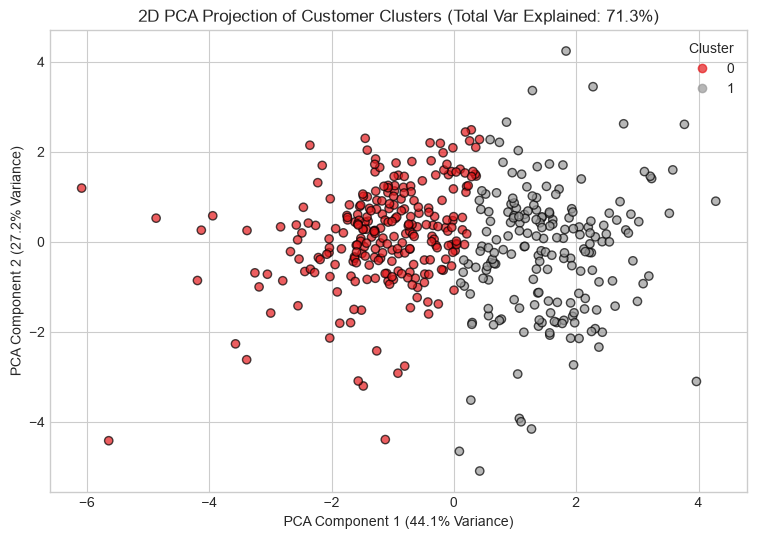

In [9]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)

# Fit mô hình K-Means (k=2) cuối cùng
final_kmeans = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
final_labels = final_kmeans.fit_predict(X_scaled_log)

# PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled_log)
var_explained = pca.explained_variance_ratio_

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='Set1', alpha=0.7, edgecolors='k')
plt.xlabel(f'PCA Component 1 ({var_explained[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({var_explained[1]*100:.1f}% Variance)')
plt.title(f'2D PCA Projection of Customer Clusters (Total Var Explained: {sum(var_explained)*100:.1f}%)')
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

Kích thước cụm:
0    252
1    188
Name: count, dtype: int64
Tỷ lệ: {0: 57.3, 1: 42.7}

Profile theo median (đơn vị chi tiêu gốc):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"10,347.50","1,871.00","2,406.00","2,225.00",327.50,749.50
1,"5,406.50","7,690.50","11,527.00","1,061.50","4,495.00","1,388.50"



Profile theo mean (đơn vị chi tiêu gốc):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,"13,973.00","2,402.00","2,919.00","3,706.00",492.00,"1,038.00"
1,"9,356.00","10,346.00","14,697.00","2,222.00","6,085.00","2,177.00"



Đối chiếu cụm với Channel (chỉ để sanity-check, không dùng để fit):


Channel,1,2
cluster,,
0,244,8
1,54,134


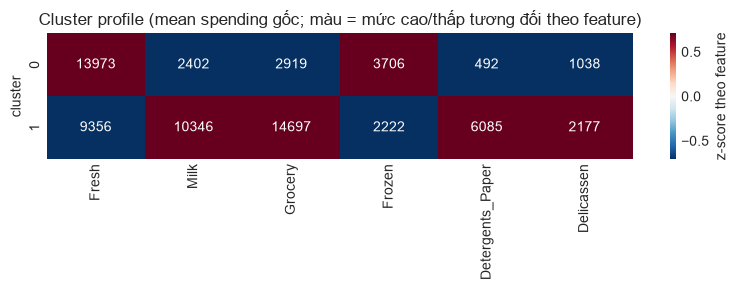

In [10]:
## Profile trên đơn vị chi tiêu gốc (X_raw)
labels_final = final_labels  # nhãn từ K-Means k=2 (TODO F)

cluster_sizes = pd.Series(labels_final).value_counts().sort_index()
print('Kích thước cụm:')
print(cluster_sizes)
print(f'Tỷ lệ: {(cluster_sizes / cluster_sizes.sum() * 100).round(1).to_dict()}')

profile_median = X_raw.assign(cluster=labels_final).groupby('cluster').median()
profile_mean = X_raw.assign(cluster=labels_final).groupby('cluster').mean().round(0)
print('\nProfile theo median (đơn vị chi tiêu gốc):')
display(profile_median)
print('\nProfile theo mean (đơn vị chi tiêu gốc):')
display(profile_mean)

# Sanity check: so cụm tìm được với Channel đã biết trước (không dùng để fit model)
if 'Channel' in df.columns:
    crosstab = pd.crosstab(labels_final, df['Channel'])
    crosstab.index.name = 'cluster'
    print('\nĐối chiếu cụm với Channel (chỉ để sanity-check, không dùng để fit):')
    display(crosstab)

# Heatmap chuẩn hoá theo cột để dễ so sánh pattern giữa 2 cụm
profile_z = (profile_mean - profile_mean.mean()) / profile_mean.std()
plt.figure(figsize=(8, 3))
sns.heatmap(profile_z, annot=profile_mean, fmt='.0f', cmap='RdBu_r', center=0, cbar_kws={'label': 'z-score theo feature'})
plt.title('Cluster profile (mean spending gốc; màu = mức cao/thấp tương đối theo feature)')
plt.tight_layout()
plt.show()

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


1. Segmentation này có thể dùng ở mức thử nghiệm giới hạn, chưa nên triển khai đại trà ngay. Hai cụm khách hàng tách biệt tương đối rõ theo pattern chi tiêu — không mạnh đến mức chắc chắn tuyệt đối (silhouette ~0.29), nhưng đủ ổn định qua kiểm tra bootstrap (ARI cao qua 100 lần resample 80% dữ liệu) để tin rằng đây không phải nhiễu ngẫu nhiên.

2. Model & evidence: K-Means (k=2) trên dữ liệu đã log1p + chuẩn hoá (StandardScaler) được chọn thay vì DBSCAN (silhouette cao hơn nhưng loại bỏ tới 76% điểm dữ liệu làm noise, không dùng được cho toàn bộ khách hàng) hoặc K-Means/Agglomerative với k lớn hơn (silhouette giảm dần, không có bằng chứng cho cấu trúc nhiều hơn 2 nhóm).

3. Hai insight quan trọng nhất: (1) Cụm 0 (~57% khách hàng) chi mạnh cho Fresh/Frozen, chi rất ít cho Grocery/Detergents_Paper — giống hồ sơ khách hàng HoReCa (nhà hàng, khách sạn); (2) Cụm 1 (~43%) ngược lại, chi mạnh cho Grocery/Milk/Detergents_Paper — giống hồ sơ Retail. Đối chiếu với biến Channel có sẵn củng cố cách diễn giải này.

4. Action đề xuất thử trước: chạy một chương trình ưu đãi thí điểm khác nhau cho hai nhóm (ví dụ giao hàng nhanh hàng tươi cho cụm 0, chiết khấu theo khối lượng hàng tạp hóa cho cụm 1) trên một tập con khách hàng, rồi đo tỷ lệ chuyển đổi/tăng trưởng chi tiêu để kiểm chứng hypothesis trước khi mở rộng.

5. Giới hạn quan trọng nhất: phân tích chỉ dựa trên tổng chi tiêu theo ngành hàng trong một năm, không có tần suất mua hàng hay lợi nhuận biên; ranh giới cụm không hoàn toàn tách biệt (silhouette trung bình-yếu), nên cần dữ liệu giao dịch chi tiết hơn trước khi biến insight thành quyết định kinh doanh chính thức.